In [1]:
import pandas as pd

# LLM results loading
snp_res = pd.read_csv("parquet/animals_snp_evaluation_results.csv")
indel_res = pd.read_csv("parquet/animals_indel_evaluation_results_2.csv")

# delta files loading
deltas = pd.read_parquet("parquet/omia_all_species_inferred_full.parquet")

In [36]:
snp_res["species_key"] = snp_res["#VariationID"].map(deltas["species_key"])

In [38]:
indel_res["species_key"] = indel_res["#VariationID"].map(deltas["species_key"])

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8,5))

order = ["CONCORDANT", "DISCORDANT"]

# ---------- SNP ----------
snp_counts = (
    snp_res["concordance"]
    .value_counts()
    .reindex(order, fill_value=0)
)

snp_pct = snp_counts / snp_counts.sum() * 100

axes[0].bar(order, snp_pct.values, color=["green","red"])

axes[0].set_title(f"Animals SNPs Concordance, n={len(snp_res)}")
axes[0].set_ylabel("% of variants")

axes[0].set_xticklabels([f"{k}\n(n={v})" for k,v in snp_counts.items()])


# ---------- INDEL ----------
indel_counts = (
    indel_res["concordance"]
    .value_counts()
    .reindex(order, fill_value=0)
)

indel_pct = indel_counts / indel_counts.sum() * 100

axes[1].bar(order, indel_pct.values, color=["green","red"])

axes[1].set_title(f"Animals Indels Concordance, n={len(indel_res)}")
axes[1].set_ylabel("% of variants")

axes[1].set_xticklabels([f"{k}\n(n={v})" for k,v in indel_counts.items()])

plt.tight_layout()

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

order = ["CONCORDANT", "DISCORDANT"]

# combine results
snp_tmp = snp_res.copy()
snp_tmp["variant_type"] = "SNP"

indel_tmp = indel_res.copy()
indel_tmp["variant_type"] = "INDEL"

res = pd.concat([snp_tmp, indel_tmp], ignore_index=True)

# define "accuracy" = fraction concordant
res["is_correct"] = res["concordance"].eq("CONCORDANT")

# per species × type summary
by = (res
      .groupby(["species_key", "variant_type"])
      .agg(
          n=("is_correct", "size"),
          accuracy=("is_correct", "mean")
      )
      .reset_index())

by["accuracy_pct"] = by["accuracy"] * 100

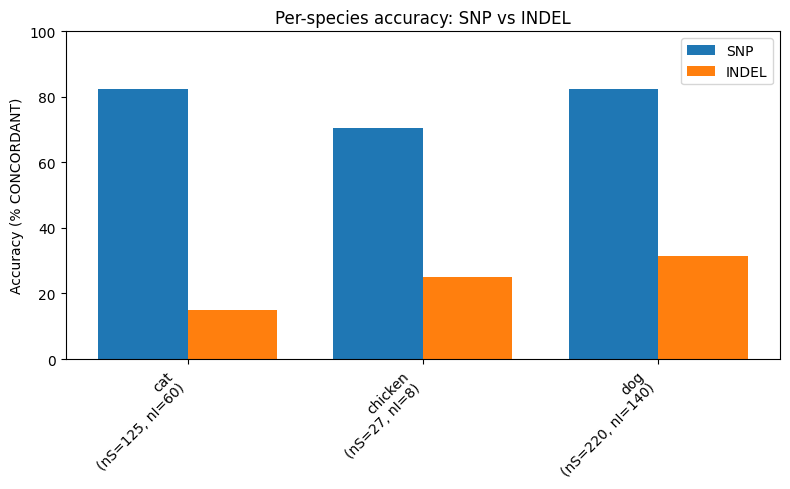

In [40]:
# pivot for grouped bar plot
piv = by.pivot(index="species_key", columns="variant_type", values="accuracy_pct").fillna(0)
n_piv = by.pivot(index="species_key", columns="variant_type", values="n").fillna(0).astype(int)

species = piv.index.tolist()
x = np.arange(len(species))
w = 0.38

fig, ax = plt.subplots(figsize=(max(8, 0.6*len(species)), 5))

ax.bar(x - w/2, piv.get("SNP", pd.Series(0, index=piv.index)).values, width=w, label="SNP")
ax.bar(x + w/2, piv.get("INDEL", pd.Series(0, index=piv.index)).values, width=w, label="INDEL")

ax.set_ylabel("Accuracy (% CONCORDANT)")
ax.set_title("Per-species accuracy: SNP vs INDEL")
ax.set_xticks(x)

# add counts to x labels (nSNP / nINDEL)
labels = []
for sp in species:
    ns = n_piv.loc[sp, "SNP"] if "SNP" in n_piv.columns else 0
    ni = n_piv.loc[sp, "INDEL"] if "INDEL" in n_piv.columns else 0
    labels.append(f"{sp}\n(nS={ns}, nI={ni})")

ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()

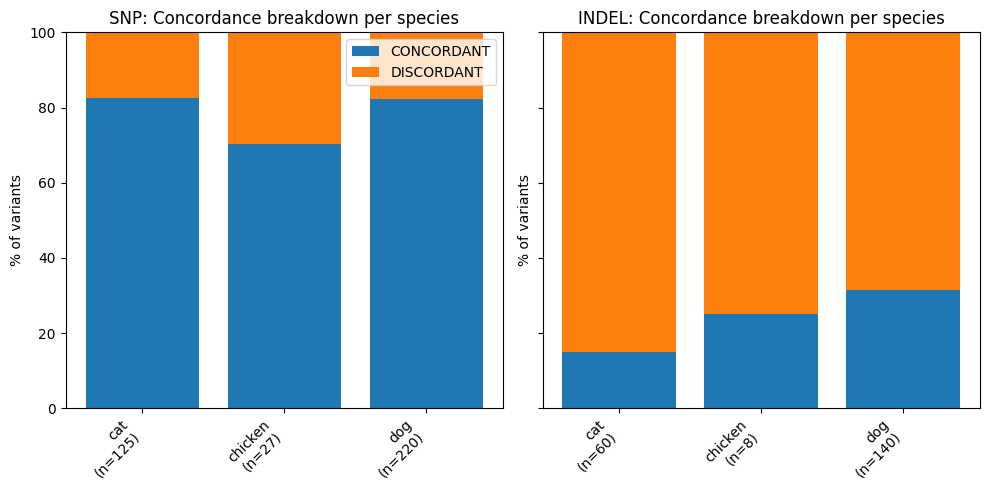

In [41]:
# counts per species × type × concordance
counts = (res.groupby(["species_key","variant_type","concordance"])
            .size()
            .unstack("concordance")
            .reindex(columns=order, fill_value=0)
            .reset_index())

counts["total"] = counts[order].sum(axis=1)
for c in order:
    counts[c+"_pct"] = counts[c] / counts["total"].replace(0, np.nan) * 100

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(max(10, 0.7*len(res["species_key"].unique())), 5), sharey=True)

for j, vt in enumerate(["SNP","INDEL"]):
    sub = counts[counts["variant_type"] == vt].set_index("species_key").reindex(species).fillna(0)
    x = np.arange(len(sub.index))

    axes[j].bar(x, sub["CONCORDANT_pct"].values, label="CONCORDANT")
    axes[j].bar(x, sub["DISCORDANT_pct"].values, bottom=sub["CONCORDANT_pct"].values, label="DISCORDANT")

    axes[j].set_title(f"{vt}: Concordance breakdown per species")
    axes[j].set_ylabel("% of variants")
    axes[j].set_xticks(x)
    axes[j].set_xticklabels([f"{sp}\n(n={int(sub.loc[sp,'total'])})" for sp in sub.index], rotation=45, ha="right")
    axes[j].set_ylim(0, 100)

axes[0].legend()
plt.tight_layout()

C:\Users\stavz\AppData\Local\Temp\ipykernel_19196\3826617973.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{sp}\n(n={joint.loc[sp,'n']})" for sp in joint.index], rotation=45, ha="right")


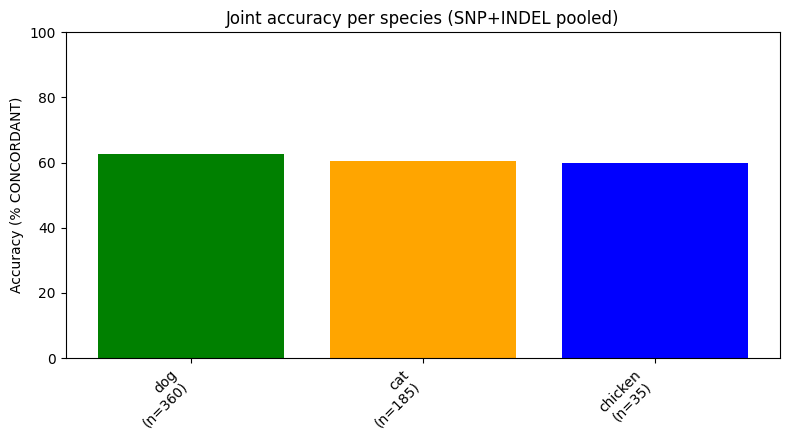

In [44]:
joint = (res.groupby("species_key")
           .agg(n=("is_correct","size"), accuracy=("is_correct","mean"))
           .assign(accuracy_pct=lambda d: d["accuracy"]*100)
           .sort_values("accuracy_pct", ascending=False))

fig, ax = plt.subplots(figsize=(max(8, 0.6*len(joint)), 4.5))
ax.bar(joint.index, joint["accuracy_pct"].values, color=["green","orange","blue"])
ax.set_ylabel("Accuracy (% CONCORDANT)")
ax.set_title("Joint accuracy per species (SNP+INDEL pooled)")
ax.set_xticklabels([f"{sp}\n(n={joint.loc[sp,'n']})" for sp in joint.index], rotation=45, ha="right")
ax.set_ylim(0, 100)
plt.tight_layout()

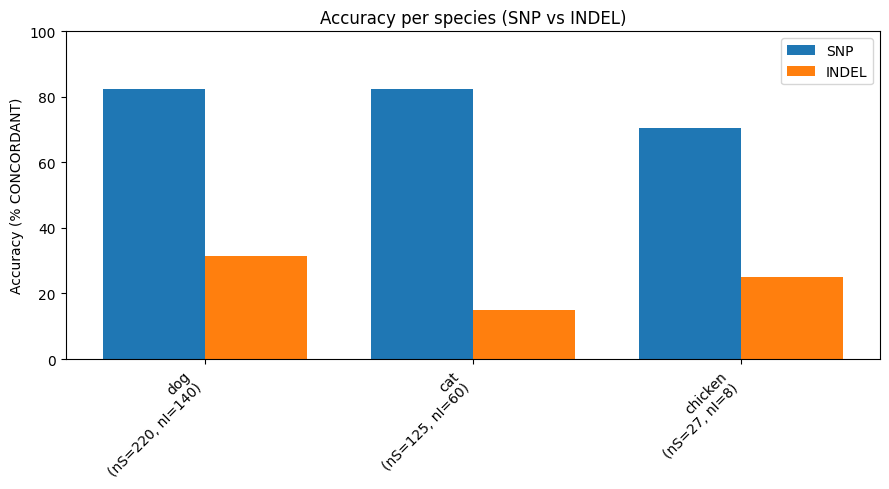

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- combine ---
snp_tmp = snp_res.copy()
snp_tmp["variant_type"] = "SNP"
indel_tmp = indel_res.copy()
indel_tmp["variant_type"] = "INDEL"
res = pd.concat([snp_tmp, indel_tmp], ignore_index=True)

# --- accuracy definition ---
res["is_correct"] = res["concordance"].eq("CONCORDANT")  # or .isin(["CONCORDANT","PARTIAL"])

# --- summary per species × type ---
by = (res.groupby(["species_key", "variant_type"])
        .agg(n=("is_correct", "size"),
             acc=("is_correct", "mean"))
        .reset_index())

by["acc_pct"] = by["acc"] * 100

# pivot for plotting
acc = by.pivot(index="species_key", columns="variant_type", values="acc_pct").fillna(0)
n_piv = by.pivot(index="species_key", columns="variant_type", values="n").fillna(0).astype(int)

# choose species order (pick ONE):
# 1) by total n
species = (n_piv.sum(axis=1).sort_values(ascending=False).index.tolist())
# 2) OR by SNP accuracy:
# species = acc.sort_values("SNP", ascending=False).index.tolist()

acc = acc.reindex(species)
n_piv = n_piv.reindex(species)

x = np.arange(len(species))
w = 0.38

fig, ax = plt.subplots(figsize=(max(9, 0.6*len(species)), 5))

ax.bar(x - w/2, acc.get("SNP", pd.Series(0, index=acc.index)).values, width=w, label="SNP")
ax.bar(x + w/2, acc.get("INDEL", pd.Series(0, index=acc.index)).values, width=w, label="INDEL")

ax.set_ylabel("Accuracy (% CONCORDANT)")
ax.set_title("Accuracy per species (SNP vs INDEL)")
ax.set_ylim(0, 100)
ax.set_xticks(x)

labels = [
    f"{sp}\n(nS={int(n_piv.loc[sp,'SNP']) if 'SNP' in n_piv.columns else 0}, "
    f"nI={int(n_piv.loc[sp,'INDEL']) if 'INDEL' in n_piv.columns else 0})"
    for sp in species
]
ax.set_xticklabels(labels, rotation=45, ha="right")

ax.legend()
plt.tight_layout()

In [47]:
res[res["signal_category"] == "STRONG"]

,concordance,explanation,signal_category,MLM_category,primary_signal_mechanism,key_signals,rationale_mechanism,nt_missed,notes,#VariationID,raw_response,parse_success,species_key,variant_type,embedding_impact,is_correct
37,CONCORDANT,"BED signals directly capture the stop-gain mechanism (increased stop_codon probability) and the resulting disruption of the open reading frame (ORF loss), perfectly matching the nonsense mutation rationale.",STRONG,MODERATE,Stop-gain/ORF disruption,"stop_codon=+0.170(ref=0.153), ORF=-0.184(ref=0.720), LLR=-0.958",Nonsense (stop-gain),False,The model correctly identifies the creation of a stop codon and the corresponding drop in predicted coding potential (ORF/exon).,63,"```json\n{\n ""explanation"": ""BED signals directly capture the stop-gain mechanism (increased stop_codon probability) and the resulting disruption of the open reading frame (ORF loss), perfectly matching the nonsense mutation rationale."",\n ""concordance"": ""CONCORDANT"",\n ""signal_category"": ""ST...",True,dog,SNP,NaN,True
130,CONCORDANT,"NT strongly predicts splice donor loss and decreased exon probability, directly supporting the ClinVar rationale of exon skipping leading to the removal of exon 2.",STRONG,MODERATE,Splice donor disruption,"BED: splice_donor=-0.476(ref=0.752), exon=-0.388(ref=0.756); MLM: LLR=-1.052, MLM_Delta=-0.369",Splice region variant leading to exon skipping and protein deletion (p.Gly48_Tyr77del),False,The high delta for splice donor loss matches the reported mechanism of exon deletion perfectly.,224,"```json\n{\n ""explanation"": ""NT strongly predicts splice donor loss and decreased exon probability, directly supporting the ClinVar rationale of exon skipping leading to the removal of exon 2."",\n ""concordance"": ""CONCORDANT"",\n ""signal_category"": ""STRONG"",\n ""MLM_category"": ""MODERATE"",\n ""p...",True,dog,SNP,NaN,True
168,CONCORDANT,"BED signals show a strong gain in stop_codon probability (+0.34) and a corresponding loss in ORF signal (-0.23), perfectly matching the ClinVar nonsense (stop-gain) rationale.",STRONG,MODERATE,Nonsense-mediated disruption (stop-gain),"BED: stop_codon=+0.341, ORF=-0.230; MLM: LLR=-1.624, LogProb_Delta=-0.7",nonsense (stop-gain),False,The gain in stop_codon signal and loss of ORF are classic indicators for a nonsense mutation in NT's BED features.,282,"```json\n{\n ""explanation"": ""BED signals show a strong gain in stop_codon probability (+0.34) and a corresponding loss in ORF signal (-0.23), perfectly matching the ClinVar nonsense (stop-gain) rationale."",\n ""concordance"": ""CONCORDANT"",\n ""signal_category"": ""STRONG"",\n ""MLM_category"": ""MODE...",True,dog,SNP,NaN,True
283,CONCORDANT,"BED signals strongly support a stop-gain mechanism through significant loss of ORF and exon probabilities, coupled with a gain in the stop_codon feature.",STRONG,MODERATE,ORF disruption and Stop codon gain,"ORF=-0.365(ref=0.781), exon=-0.323(ref=0.755), stop_codon=+0.133(ref=0.069); LLR=-0.796",nonsense (stop-gain),False,The model correctly identifies the gain of a stop codon and the resulting loss of ORF/Exon identity.,454,"```json\n{\n ""explanation"": ""BED signals strongly support a stop-gain mechanism through significant loss of ORF and exon probabilities, coupled with a gain in the stop_codon feature."",\n ""concordance"": ""CONCORDANT"",\n ""signal_category"": ""STRONG"",\n ""MLM_category"": ""MODERATE"",\n ""primary_sig...",True,cat,SNP,NaN,True
